In [34]:
!pip install catboost -q
!pip install optuna -q
!pip install shap -q

In [35]:
import os
from google.colab import userdata

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import shap

from catboost import CatBoostRegressor

sns.set_theme(style="whitegrid")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# EDA и baseline

In [3]:
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

!kaggle competitions download -c demand-forecasting-kernels-only
!unzip -q demand-forecasting-kernels-only.zip -d ./data/

100% 3.29M/3.29M [00:00<00:00, 134MB/s]



In [4]:
df = pd.read_csv('./data/train.csv')
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [5]:
df['date'] = pd.to_datetime(df['date'])

# Сортируем по времени
df = df.sort_values(['store', 'item', 'date']).reset_index(drop=True)
print("Пропуски:\n", df.isna().sum())

Пропуски:
 date     0
store    0
item     0
sales    0
dtype: int64


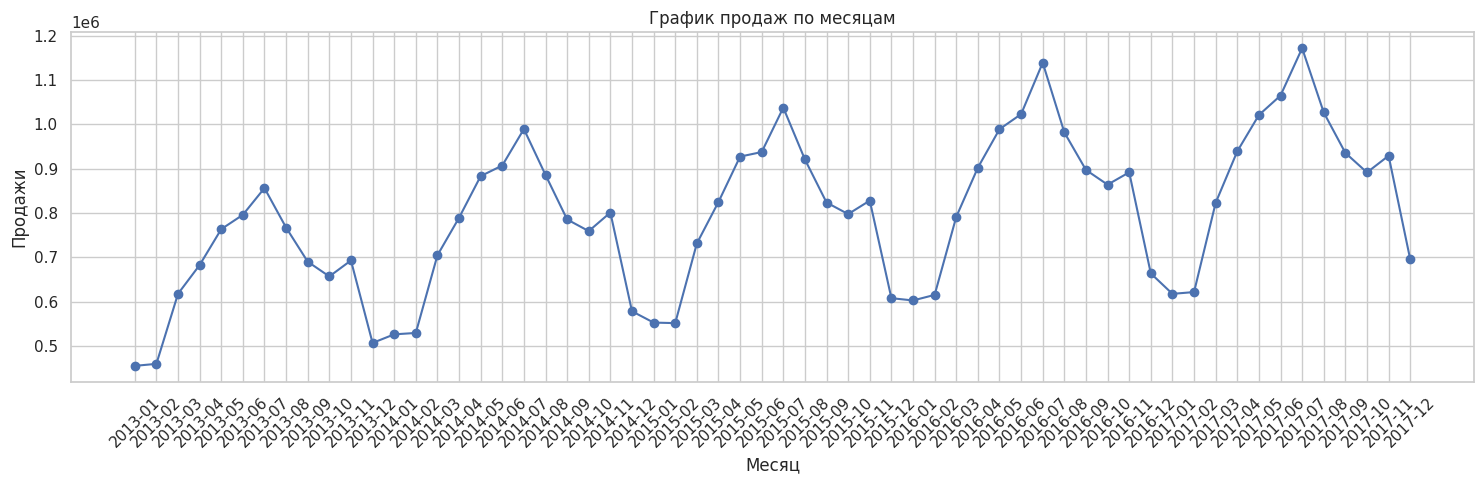

In [6]:
# Агрегируем продажи по месяцам
df['month_year'] = df['date'].dt.to_period('M')

monthly_sales = df.groupby('month_year')['sales'].sum().reset_index()
monthly_sales['month_year'] = monthly_sales['month_year'].astype(str)

# Строим график
plt.figure(figsize=(15, 5))
plt.plot(monthly_sales['month_year'], monthly_sales['sales'], marker='o')
plt.xticks(rotation=45)
plt.xlabel('Месяц')
plt.ylabel('Продажи')
plt.title('График продаж по месяцам')
plt.tight_layout()
plt.show()

В качестве метрики будем использовать WAPE

In [7]:
def wape(y_true, y_pred):
  total_sales = np.sum(np.abs(y_true))
  return np.sum(np.abs(y_true - y_pred)) / total_sales

Строим наивный прогноз, предполагая, что завтра купят столько же товара, сколько и сегодня

In [8]:
# Создаем колонку с наивным прогнозом
df['baseline_pred'] = df.groupby(['store', 'item'])['sales'].shift(1)

# Удаляем первую строку для каждой группы, так как там образуется NaN (у нас нет данных за "вчера" для первого дня)
df_baseline = df.dropna(subset=['baseline_pred'])

# Считаем WAPE
baseline_score = wape(df_baseline['sales'], df_baseline['baseline_pred'])
print(f"Baseline WAPE: {baseline_score:.4f}")

Baseline WAPE: 0.1983


# Feature Engineering

В прогнозировании спроса обычно используют три типа фичей:

Temporal: День недели, месяц, год, выходной/рабочий день. Помогают модели выучить сезонность.

Lag: Продажи этого же товара в этом же магазине 1 день назад, 2 дня назад, неделю назад.

Rolling features: Скользящие средние. Например, средние продажи за последние 7 дней. Это сглаживает случайные всплески и показывает локальный тренд.

In [9]:
def create_features(df):
  df_feat = df.copy()

  # Temporal
  df_feat['day_of_week'] = df_feat['date'].dt.dayofweek
  df_feat['month'] = df_feat['date'].dt.month
  df_feat['year'] = df_feat['date'].dt.year
  df_feat['is_weekend'] = df_feat['day_of_week'].isin([5, 6]).astype(int)

  df_feat = df_feat.sort_values(['store', 'item', 'date']).reset_index(drop=True)

  # Lags
  lags = [1, 2, 3, 7]
  for lag in lags:
    df_feat[f'sales_lag_{lag}'] = df_feat.groupby(['store', 'item'])['sales'].shift(lag)

  # Rolling windows
  windows = [7, 14]
  for window in windows:
    df_feat[f'rolling_mean_{window}'] = (
        df_feat.groupby(['store', 'item'])['sales']
        .transform(lambda x: x.shift(1).rolling(window).mean())
    )

  df_feat = df_feat.dropna().reset_index(drop=True)

  return df_feat


In [10]:
df_features = create_features(df)
print('Размер датасета: ', df_features.shape)
df_features.head()

Размер датасета:  (906000, 16)


,date,store,item,sales,month_year,baseline_pred,day_of_week,month,year,is_weekend,sales_lag_1,sales_lag_2,sales_lag_3,sales_lag_7,rolling_mean_7,rolling_mean_14
0,2013-01-15,1,1,5,2013-01,12.0,1,1,2013,0,12.0,10.0,7.0,9.0,9.714286,10.785714
1,2013-01-16,1,1,7,2013-01,5.0,2,1,2013,0,5.0,12.0,10.0,12.0,9.142857,10.214286
2,2013-01-17,1,1,16,2013-01,7.0,3,1,2013,0,7.0,5.0,12.0,9.0,8.428571,9.928571
3,2013-01-18,1,1,7,2013-01,16.0,4,1,2013,0,16.0,7.0,5.0,9.0,9.428571,10.071429
4,2013-01-19,1,1,18,2013-01,7.0,5,1,2013,1,7.0,16.0,7.0,7.0,9.142857,9.642857


# Time Series Split

Разобъем выбору по времени, чтобы не допустить утечку данных, и модель не обучалась на данных из будущего

In [17]:
# Оставим на тест последние 90 дней
max_date = df_features['date'].max()
split_date = max_date - pd.Timedelta(days=90)

train = df_features[df_features['date'] <= split_date]
test = df_features[df_features['date'] > split_date]

# Отделяем таргет от фичей
drop_cols = ['date', 'sales', 'baseline_pred', 'month_year']

X_train = train.drop(columns=drop_cols)
y_train = train['sales']

X_test = test.drop(columns=drop_cols)
y_test = test['sales']

print(f'Обучающая выборка: {X_train.shape[0]} строк')
print(f'Тестовая выборка: {X_test.shape[0]} строк')

Обучающая выборка: 861000 строк
Тестовая выборка: 45000 строк


# Обучение модели

In [18]:
cat_features = ['store', 'item', 'day_of_week', 'month', 'year', 'is_weekend']

model = CatBoostRegressor(
    iterations=800,
    learning_rate=0.05,
    depth=6,
    loss_function='MAE', # Оптимизируем MAE, т.к. WAPE строится на модуле разности
    eval_metric='MAE',
    random_seed=42,
    verbose=100
)

In [13]:
model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50
)

0:	learn: 21.8514633	test: 22.0678856	best: 22.0678856 (0)	total: 1.29s	remaining: 17m 8s
100:	learn: 6.0953714	test: 6.5048023	best: 6.5048023 (100)	total: 1m 40s	remaining: 11m 35s
200:	learn: 5.9397012	test: 6.2767343	best: 6.2767343 (200)	total: 3m 9s	remaining: 9m 24s
300:	learn: 5.8706410	test: 6.1819876	best: 6.1819876 (300)	total: 4m 41s	remaining: 7m 46s
400:	learn: 5.8196303	test: 6.1241730	best: 6.1236826 (382)	total: 6m 17s	remaining: 6m 15s
500:	learn: 5.7809474	test: 6.0606956	best: 6.0597149 (498)	total: 8m 2s	remaining: 4m 48s
600:	learn: 5.7514561	test: 6.0290110	best: 6.0290110 (600)	total: 9m 42s	remaining: 3m 12s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 6.023989043
bestIteration = 613

Shrink model to first 614 iterations.


CatBoostRegressor(depth=6, eval_metric='MAE', iterations=800, learning_rate=0.05, loss_function='MAE', random_seed=42, verbose=100)

In [14]:
y_pred = model.predict(X_test)

catboost_wape = wape(y_test, y_pred)

print(f'Итоговая WAPE Catboost: {catboost_wape:.4f}')

Итоговая WAPE Catboost: 0.1103


Интерпретируем результаты:

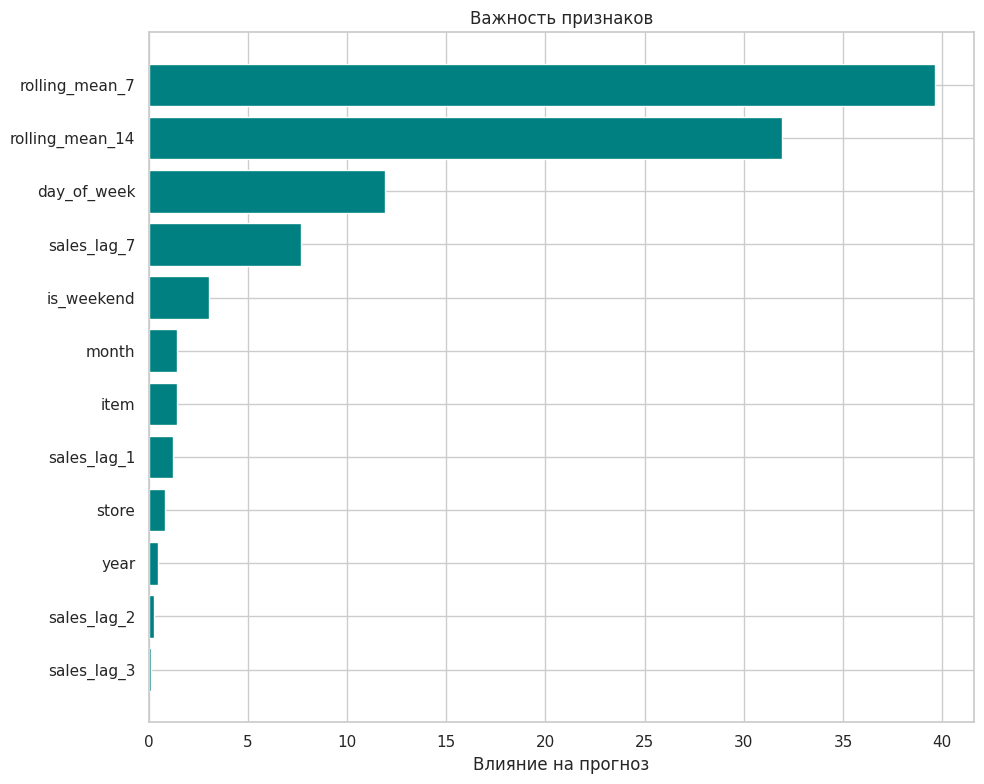

In [15]:
# Получаем важность признаков
feature_importance = model.get_feature_importance()
sorted_idx = np.argsort(feature_importance)

plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center', color='teal')
plt.yticks(range(len(sorted_idx)), np.array(X_train.columns)[sorted_idx])
plt.title('Важность признаков')
plt.xlabel('Влияние на прогноз')
plt.tight_layout()
plt.show()

# Итерация 2

Заметим, что сгенерированные нами лаги для 2 и 3 дней назад почти не влияют на прогноз, а лишь создают шум. Уберем их

In [16]:
def create_features(df):
  df_feat = df.copy()

  # Temporal
  df_feat['day_of_week'] = df_feat['date'].dt.dayofweek
  df_feat['month'] = df_feat['date'].dt.month
  df_feat['year'] = df_feat['date'].dt.year
  df_feat['is_weekend'] = df_feat['day_of_week'].isin([5, 6]).astype(int)

  df_feat = df_feat.sort_values(['store', 'item', 'date']).reset_index(drop=True)

  # Lags
  lags = [1, 7] # Убрали 2 и 3 дня
  for lag in lags:
    df_feat[f'sales_lag_{lag}'] = df_feat.groupby(['store', 'item'])['sales'].shift(lag)

  # Rolling windows
  windows = [7, 14]
  for window in windows:
    df_feat[f'rolling_mean_{window}'] = (
        df_feat.groupby(['store', 'item'])['sales']
        .transform(lambda x: x.shift(1).rolling(window).mean())
    )

  df_feat = df_feat.dropna().reset_index(drop=True)

  return df_feat


df_features = create_features(df)
print('Размер датасета: ', df_features.shape)
df_features.head()

Размер датасета:  (906000, 14)


,date,store,item,sales,month_year,baseline_pred,day_of_week,month,year,is_weekend,sales_lag_1,sales_lag_7,rolling_mean_7,rolling_mean_14
0,2013-01-15,1,1,5,2013-01,12.0,1,1,2013,0,12.0,9.0,9.714286,10.785714
1,2013-01-16,1,1,7,2013-01,5.0,2,1,2013,0,5.0,12.0,9.142857,10.214286
2,2013-01-17,1,1,16,2013-01,7.0,3,1,2013,0,7.0,9.0,8.428571,9.928571
3,2013-01-18,1,1,7,2013-01,16.0,4,1,2013,0,16.0,9.0,9.428571,10.071429
4,2013-01-19,1,1,18,2013-01,7.0,5,1,2013,1,7.0,7.0,9.142857,9.642857


Далее перезапустим ячейку в Time Series Split и ячейку с инициализацией модели. Последующие ячейки продублируем для отслеживания результатов

In [19]:
model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50
)

0:	learn: 21.8519387	test: 22.0627289	best: 22.0627289 (0)	total: 1.27s	remaining: 16m 55s
100:	learn: 6.0876853	test: 6.4894592	best: 6.4894592 (100)	total: 1m 47s	remaining: 12m 22s
200:	learn: 5.9359143	test: 6.2677998	best: 6.2677998 (200)	total: 3m 17s	remaining: 9m 49s
300:	learn: 5.8697155	test: 6.1746031	best: 6.1746031 (300)	total: 4m 56s	remaining: 8m 11s
400:	learn: 5.8195755	test: 6.1074349	best: 6.1074349 (400)	total: 6m 39s	remaining: 6m 37s
500:	learn: 5.7819595	test: 6.0669127	best: 6.0652680 (483)	total: 8m 23s	remaining: 5m
600:	learn: 5.7533171	test: 6.0310165	best: 6.0310165 (600)	total: 10m 3s	remaining: 3m 19s
700:	learn: 5.7296092	test: 6.0065812	best: 6.0065812 (700)	total: 11m 46s	remaining: 1m 39s
799:	learn: 5.7112982	test: 5.9973177	best: 5.9968409 (794)	total: 13m 28s	remaining: 0us

bestTest = 5.996840886
bestIteration = 794

Shrink model to first 795 iterations.


CatBoostRegressor(depth=6, eval_metric='MAE', iterations=800, learning_rate=0.05, loss_function='MAE', random_seed=42, verbose=100)

In [20]:
y_pred = model.predict(X_test)

catboost_wape = wape(y_test, y_pred)

print(f'Итоговая WAPE Catboost: {catboost_wape:.4f}')

Итоговая WAPE Catboost: 0.1098


Получили незначительное уменьшение WAPE на 0.05%

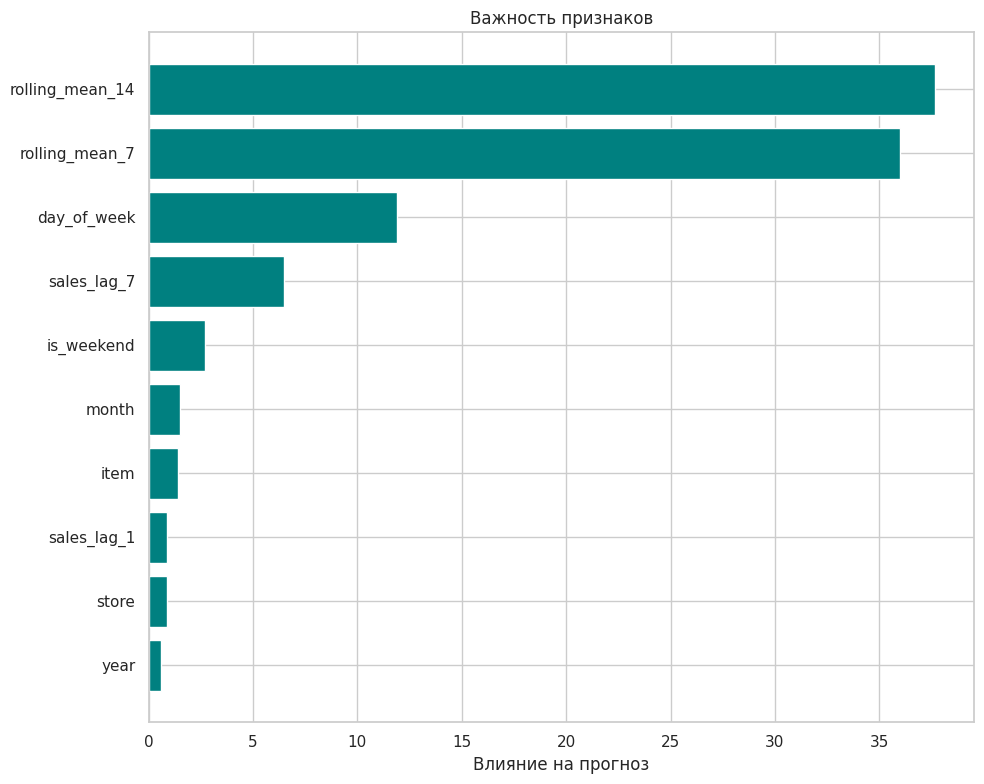

In [21]:
# Получаем важность признаков
feature_importance = model.get_feature_importance()
sorted_idx = np.argsort(feature_importance)

plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center', color='teal')
plt.yticks(range(len(sorted_idx)), np.array(X_train.columns)[sorted_idx])
plt.title('Важность признаков')
plt.xlabel('Влияние на прогноз')
plt.tight_layout()
plt.show()

# Оптимизация гиперпараметров и обучение финальной модели

In [22]:
def objective(trial):
  # Устанавливаем диапазоны
  params = {
      'iterations': trial.suggest_int('iterations', 400, 1000, step=100),
      'depth': trial.suggest_int('depth', 4, 8),
      'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
      'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
      'loss_function': 'MAE',
      'eval_metric': 'MAE',
      'random_seed': 42,
      'logging_level': 'Silent'
  }

  model = CatBoostRegressor(**params)
  model.fit(
      X_train, y_train,
      cat_features=cat_features,
      eval_set=(X_test, y_test),
      early_stopping_rounds=30
  )

  preds = model.predict(X_test)
  score = wape(y_test, preds)

  return score

In [23]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=15)

print(f'Лучшая WAPE на тесте: {study.best_value:.4f}')
print(f'Лучшие параметры:{study.best_params}')

Лучшая WAPE на тесте: 0.1097
Лучшие параметры:{'iterations': 700, 'depth': 8, 'learning_rate': 0.08247031559150578, 'l2_leaf_reg': 1.0163572505741592}


Получили снижение WAPE лишь на 0.01%, т.е. изначально параметры были подобраны хорошо. Всё же для конечной модели используем гиперпараметры, найденные с помощью Optuna

In [24]:
best_params = study.best_params

final_model = CatBoostRegressor(**best_params)
final_model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50,
    verbose=100
)

final_preds = final_model.predict(X_test)
print(f'Финальная WAPE после очистки фичей и подбора оптимальных гиперпараметров: {wape(y_test, final_preds) * 100:.2f}%')

0:	learn: 26.7742905	test: 26.4594012	best: 26.4594012 (0)	total: 1.47s	remaining: 17m 8s
100:	learn: 7.6782237	test: 8.0258641	best: 8.0258641 (100)	total: 1m 57s	remaining: 11m 33s
200:	learn: 7.4994376	test: 7.8774187	best: 7.8774187 (200)	total: 4m 3s	remaining: 10m 5s
300:	learn: 7.4070369	test: 7.8397765	best: 7.8386483 (281)	total: 6m 10s	remaining: 8m 11s
400:	learn: 7.3571398	test: 7.8270960	best: 7.8248283 (396)	total: 8m 20s	remaining: 6m 12s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 7.814908928
bestIteration = 435

Shrink model to first 436 iterations.
Финальная WAPE после очистки фичей и подбора оптимальных гиперпараметров: 10.97%


In [39]:
# Сохраняем модель
final_model.save_model('catboost_demand_model.cbm')

# SHAP интерпретация

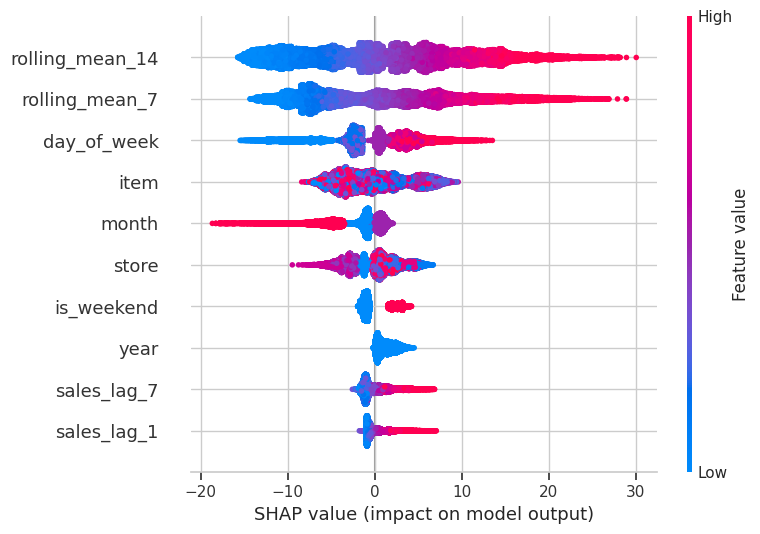

In [38]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

Ключевыми факторами являются краткосрочные тренды (скользящие средние за 7 и 14 дней). Модель успешно уловила недельную сезонность: фактор is_weekend дает чистый прирост к прогнозу. При этом единичные лаги оказались избыточными, так как их информативность была поглощена скользящими средними